# Modèle 2 — Random Forest


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error, 
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


## Chargement des données preprocessées

Mêmes données que pour la Régression Logistique.
On charge les fichiers .npy générés par le preprocessing.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Labels originaux (pour référence et régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# y_train_reg_log chargé plus bas dans la section régression
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (undersampling)")
print(f"   X_train_smote   : {X_train_smote.shape} (SMOTE)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (undersampling)
   X_train_smote   : (14366, 50) (SMOTE)
   X_test          : (2000, 50)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn

On entraîne le Random Forest sur **deux datasets** : Undersampling et SMOTE, puis on compare les métriques.

In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
rf_clf_under = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_under.fit(X_train_under, y_train_clf_under)
y_pred_under  = rf_clf_under.predict(X_test)
y_proba_under = rf_clf_under.predict_proba(X_test)[:, 1]

print("=== Random Forest — Undersampling ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_under):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
rf_clf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = rf_clf_smote.predict(X_test)
y_proba_smote = rf_clf_smote.predict_proba(X_test)[:, 1]

print("=== Random Forest — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")

# On garde le meilleur basé sur le Recall
recall_under = recall_score(y_test_clf, y_pred_under)
recall_smote = recall_score(y_test_clf, y_pred_smote)

if recall_smote >= recall_under:
    rf_clf      = rf_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    rf_clf      = rf_clf_under
    y_pred_clf  = y_pred_under
    y_proba_clf = y_proba_under
    best_technique = 'Undersampling'

print(f"\n→ Meilleure technique retenue : {best_technique} (Recall={max(recall_under, recall_smote):.4f})")

=== Random Forest — Undersampling ===
   Accuracy  : 0.7135
   Precision : 0.2420
   Recall    : 0.8480
   F1-Score  : 0.3765
   ROC-AUC   : 0.8024

=== Random Forest — SMOTE ===
   Accuracy  : 0.8865
   Precision : 0.3051
   Recall    : 0.0882
   F1-Score  : 0.1369
   ROC-AUC   : 0.7754

→ Meilleure technique retenue : Undersampling (Recall=0.8480)


## Matrice de Confusion — Comparaison Undersampling vs SMOTE

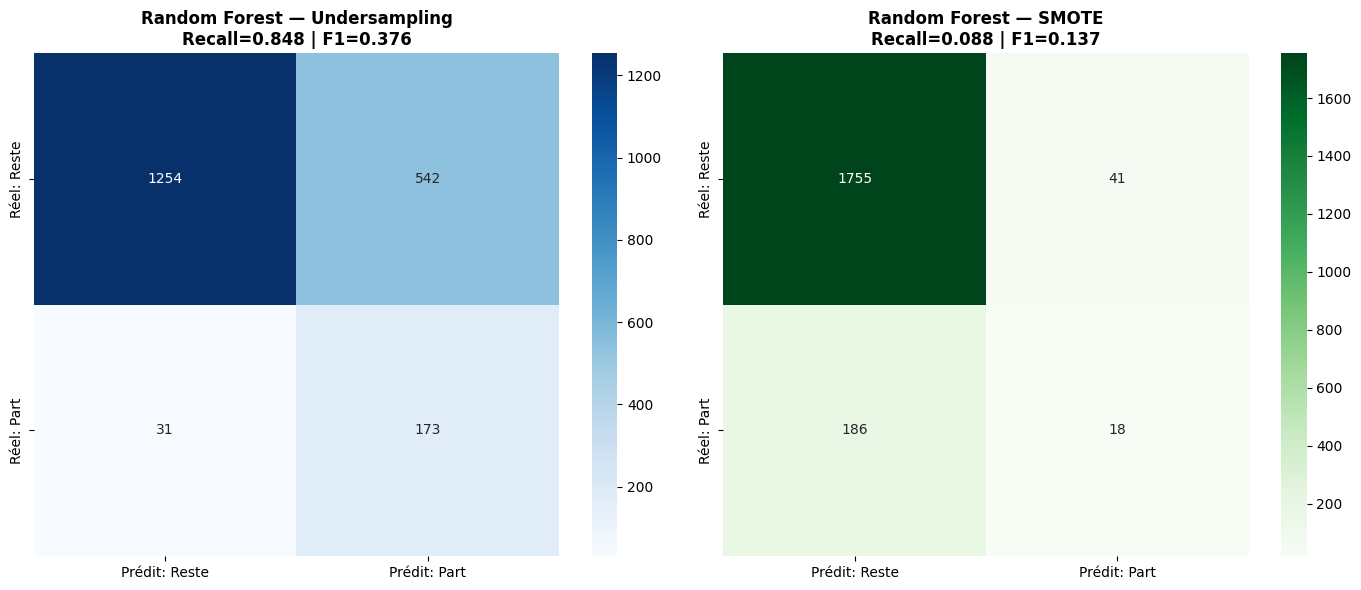


Meilleur modèle (Undersampling) :
   Vrais Négatifs  (TN) : 1254
   Faux Positifs   (FP) : 542
   Faux Négatifs   (FN) : 31 → churners manqués
   Vrais Positifs  (TP) : 173 → churners détectés


In [4]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'Random Forest — Undersampling', 'Blues'),
    (y_pred_smote, 'Random Forest — SMOTE', 'Greens'),
]):
    cm = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix.png', dpi=150)
plt.show()

# Détail meilleur modèle
cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés")

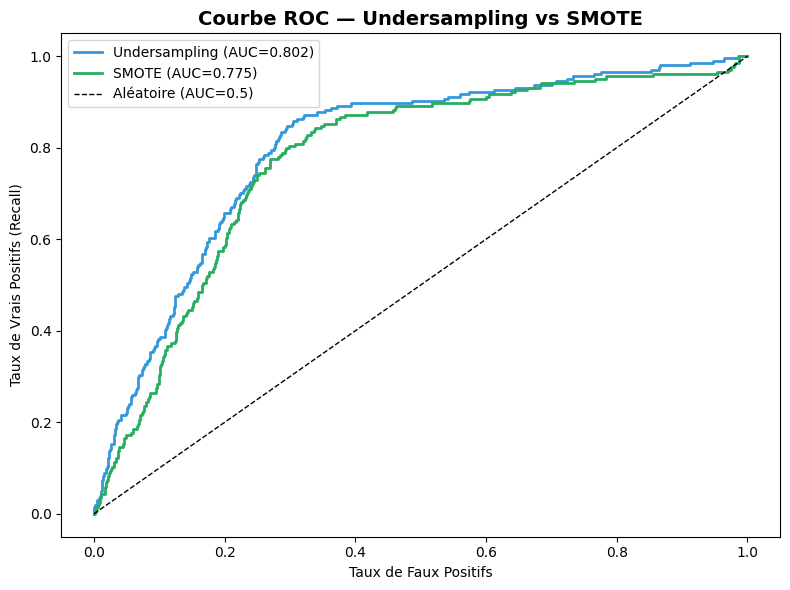

In [5]:
# COURBE ROC — Undersampling vs SMOTE

plt.figure(figsize=(8, 6))

for y_proba, label, color in [
    (y_proba_under, 'Undersampling', '#3498db'),
    (y_proba_smote, 'SMOTE',         '#27ae60'),
]:
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    auc_score = roc_auc_score(y_test_clf, y_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Undersampling vs SMOTE', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/rf_roc_curve.png', dpi=150)
plt.show()

auc = roc_auc_score(y_test_clf, y_proba_clf)

## Feature Importance


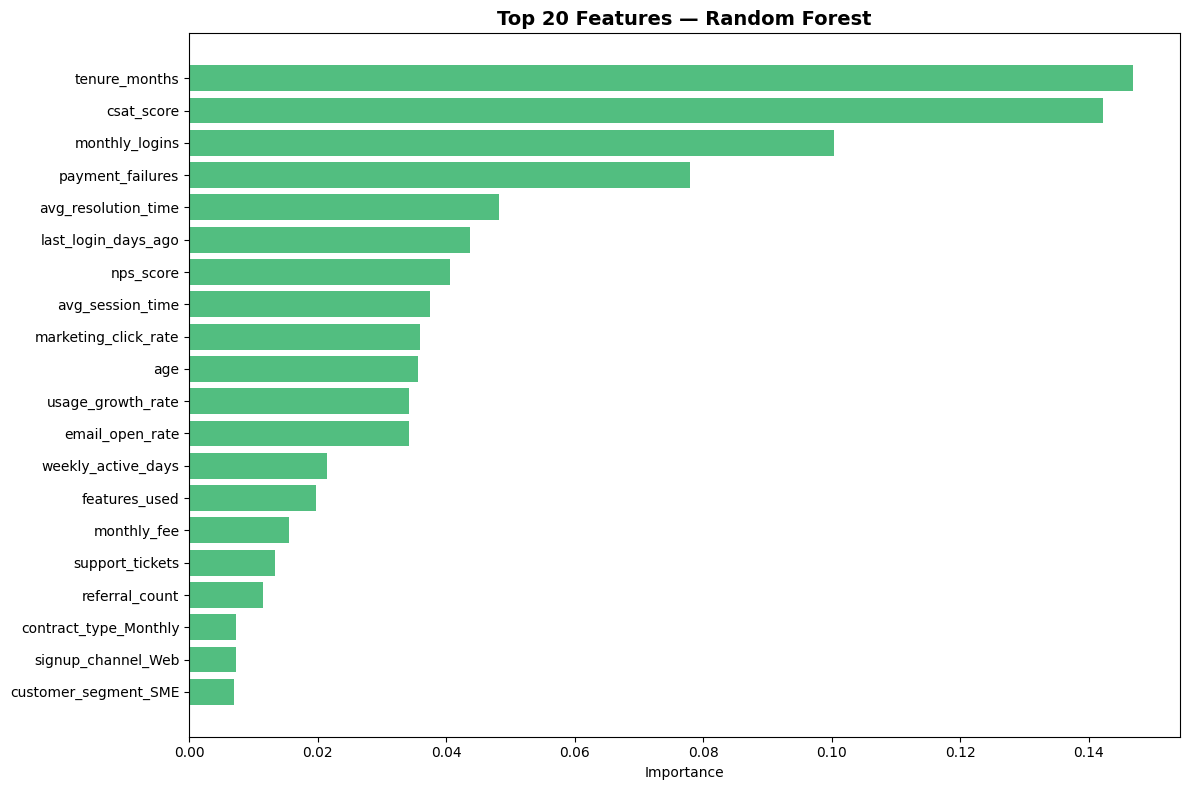


🔝 Top 10 features les plus importantes :
   1. tenure_months                       : 0.1469
   2. csat_score                          : 0.1423
   3. monthly_logins                      : 0.1004
   4. payment_failures                    : 0.0780
   5. avg_resolution_time                 : 0.0482
   6. last_login_days_ago                 : 0.0437
   7. nps_score                           : 0.0407
   8. avg_session_time                    : 0.0375
   9. marketing_click_rate                : 0.0359
   10. age                                 : 0.0356


In [6]:
# FEATURE IMPORTANCE

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(12, 8))
plt.barh(range(20), 
         importances[indices][::-1],
         color='#27ae60', alpha=0.8)
plt.yticks(range(20), 
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150)
plt.show()

print("\n🔝 Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque


In [7]:
# VÉRIFICATION AVANT ENTRAÎNEMENT
X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

print("Vérification des données régression :")
print(f"  X_train_reg shape : {X_train_reg.shape}")
print(f"  y_train_reg_log shape : {y_train_reg_log.shape}")
print(f"  y_train_reg_log min : {y_train_reg_log.min():.2f}")
print(f"  y_train_reg_log max : {y_train_reg_log.max():.2f}")
print(f"  y_test_reg shape : {y_test_reg.shape}")
print(f"  y_test_reg — nb zeros : {(y_test_reg == 0).sum()}")
print(f"  y_test_reg — nb churners : {(y_test_reg > 0).sum()}")

# Vérifier que total_revenue n'est PAS dans X_train_reg
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()
print(f"\n  Features contenant 'revenue' : {[f for f in feature_names if 'revenue' in f.lower()]}")
print(f"  Features contenant 'total' : {[f for f in feature_names if 'total' in f.lower()]}")

Vérification des données régression :
  X_train_reg shape : (817, 50)
  y_train_reg_log shape : (817,)
  y_train_reg_log min : 2.40
  y_train_reg_log max : 8.61
  y_test_reg shape : (2000,)
  y_test_reg — nb zeros : 1796
  y_test_reg — nb churners : 204

  Features contenant 'revenue' : []
  Features contenant 'total' : []


In [8]:
# TÂCHE 2 — RÉGRESSION Random Forest

X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,          # réduit (était 10)
    min_samples_leaf=20,  # augmenté (était 5) → force la généralisation
    max_features=0.5,     # utilise seulement 50% des features par split
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train_reg, y_train_reg_log)

y_pred_reg_log = rf_reg.predict(X_test)
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print("Modèle de régression entraîné !")
print(f"\nRésultats — Random Forest Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Random Forest Regression (churners uniquement)
   MAE  : 181.89 €
   RMSE : 434.38 €
   R²   : 0.7911


In [9]:
# SAUVEGARDE

# Sauvegarde du meilleur modèle (sélectionné automatiquement)
print(f"Sauvegarde du modèle : {best_technique}")
joblib.dump(rf_clf, '../models/rf_classification.pkl')
joblib.dump(rf_reg, '../models/rf_regression.pkl')

results_clf = {
    'model'    : 'Random Forest (' + best_technique + ')',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Random Forest Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/rf_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/rf_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du modèle : Undersampling
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

Résumé Classification :
   accuracy   : 0.7135
   precision  : 0.2420
   recall     : 0.8480
   f1         : 0.3765
   roc_auc    : 0.8024


## Synthèse — Random Forest
